11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Metrics to show
- Accuracy:  0.5558
- Precision: 0.6917
- Recall:    0.5558
- F1-Score:  0.5170


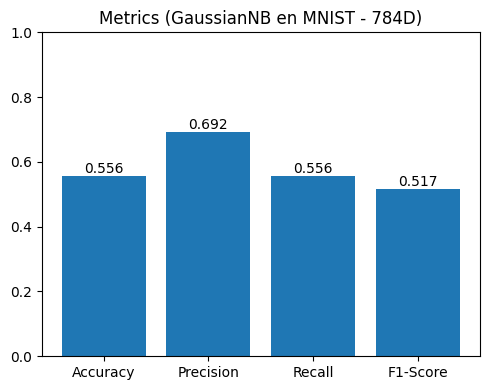

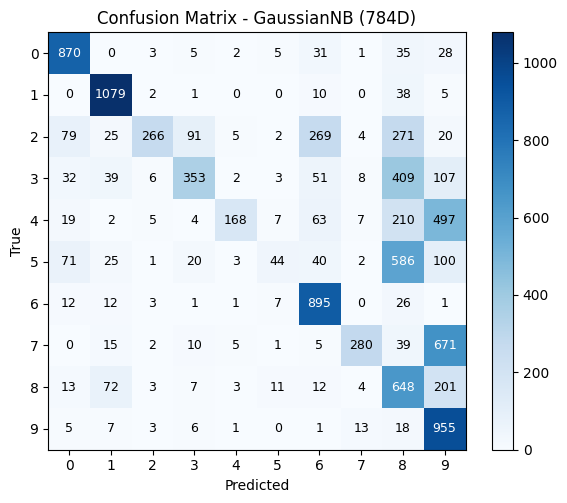

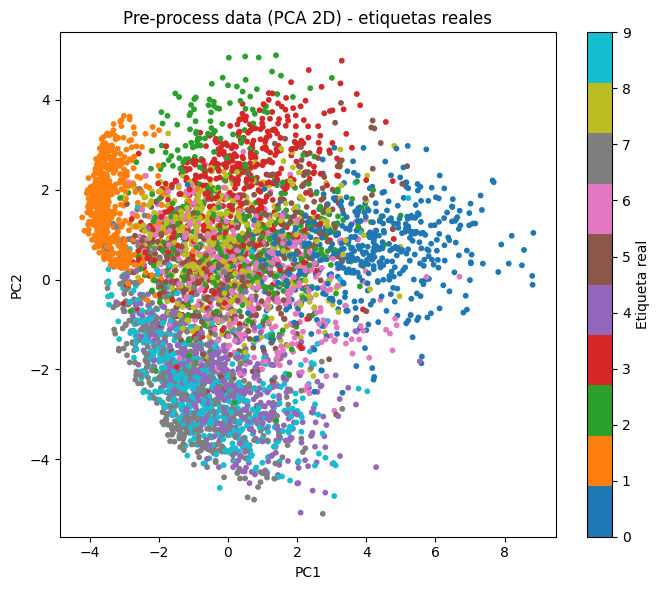

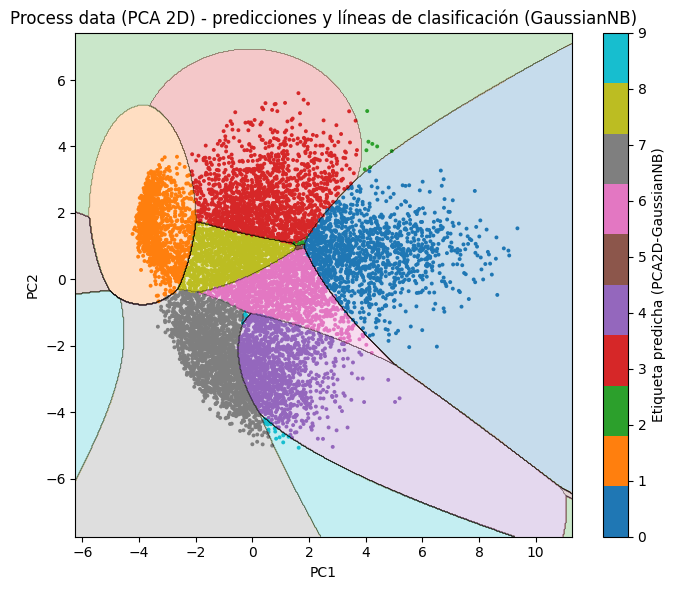

In [1]:
# ============================================
# MNIST + GaussianNB (Naive Bayes Gaussiano)
# Entrenamiento en 784D (pixeles aplanados)
# Visualización con PCA 2D (clusters + líneas de clasificación)
# Métricas: Accuracy, Precision, Recall, F1-Score
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA

# -----------------------------
# 1) Cargar MNIST
# -----------------------------
from tensorflow.keras.datasets import mnist
np.random.seed(42)

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

# -----------------------------
# 2) Pre-proceso (784D)
# -----------------------------
X_train = (X_train_raw.astype("float32")/255.0).reshape(-1, 28*28)  # 784 features
X_test  = (X_test_raw.astype("float32")/255.0).reshape(-1, 28*28)
y_train = y_train_raw.astype(int)
y_test  = y_test_raw.astype(int)

# GaussianNB es muy rápido: puedes usar todo el train.
# Si quieres acelerar aún más, descomenta estas 3 líneas:
# TRAIN_SIZE = 20000
# idx_tr = np.random.choice(len(X_train), size=TRAIN_SIZE, replace=False)
# X_train, y_train = X_train[idx_tr], y_train[idx_tr]

# -----------------------------
# 3) Entrenar GaussianNB en 784D
# -----------------------------
gnb_main = GaussianNB(var_smoothing=1e-9)  # var_smoothing ayuda con estabilidad numérica
gnb_main.fit(X_train, y_train)

# Predicciones en TEST (784D)
y_pred = gnb_main.predict(X_test)

# -----------------------------
# 4) Métricas + barra
# -----------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Metrics to show")
print(f"- Accuracy:  {acc:.4f}")
print(f"- Precision: {prec:.4f}")
print(f"- Recall:    {rec:.4f}")
print(f"- F1-Score:  {f1:.4f}")

plt.figure(figsize=(5,4))
labels = ["Accuracy","Precision","Recall","F1-Score"]
vals = [acc,prec,rec,f1]
plt.bar(labels, vals)
plt.ylim(0,1)
for i,v in enumerate(vals):
    plt.text(i, v+0.01, f"{v:.3f}", ha="center", fontsize=10)
plt.title("Metrics (GaussianNB en MNIST - 784D)")
plt.tight_layout(); plt.show()

# -----------------------------
# 5) Matriz de confusión (TONOS AZULES)
# -----------------------------
cm = confusion_matrix(y_test, y_pred, labels=np.arange(10))

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - GaussianNB (784D)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(np.arange(10)); plt.yticks(np.arange(10))
plt.colorbar()
thr = cm.max()/2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j],
                 ha="center", va="center",
                 color="white" if cm[i,j]>thr else "black", fontsize=9)
plt.tight_layout(); plt.show()

# -----------------------------
# 6) PCA 2D SOLO para visualización
# -----------------------------
pca2 = PCA(n_components=2, random_state=42)
Xtr2_full = pca2.fit_transform(X_train)   # train → 2D
Xte2      = pca2.transform(X_test)        # test  → 2D

# ----- Graph pre-process data (PCA 2D con etiquetas REALES)
VIS_N = 5000
idx_vis = np.random.choice(len(Xtr2_full), size=min(VIS_N, len(Xtr2_full)), replace=False)

plt.figure(figsize=(7,6))
sc = plt.scatter(Xtr2_full[idx_vis,0], Xtr2_full[idx_vis,1],
                 c=y_train[idx_vis], s=10, cmap="tab10")
plt.title("Pre-process data (PCA 2D) - etiquetas reales")
plt.xlabel("PC1"); plt.ylabel("PC2")
cbar = plt.colorbar(sc, ticks=range(10)); cbar.set_label("Etiqueta real")
plt.tight_layout(); plt.show()

# -----------------------------
# 7) Process data (PCA 2D con líneas de clasificación)
#    Entrenamos otro GaussianNB en 2D SOLO para dibujar fronteras
# -----------------------------
gnb_2d = GaussianNB(var_smoothing=1e-9)
gnb_2d.fit(Xtr2_full, y_train)

# Malla para fronteras
pad = 2.0
x_min, x_max = Xtr2_full[:,0].min()-pad, Xtr2_full[:,0].max()+pad
y_min, y_max = Xtr2_full[:,1].min()-pad, Xtr2_full[:,1].max()+pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = gnb_2d.predict(grid).reshape(xx.shape)

# Predicciones en test (2D)
y_pred_2d = gnb_2d.predict(Xte2)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="tab10", levels=np.arange(-0.5,10,1))
_ = plt.contour(xx, yy, Z, colors="k", linewidths=0.3, alpha=0.6, levels=np.arange(-0.5,10,1))

sc2 = plt.scatter(Xte2[:,0], Xte2[:,1],
                  c=y_pred_2d, s=8, cmap="tab10", edgecolor="none")
plt.title("Process data (PCA 2D) - predicciones y líneas de clasificación (GaussianNB)")
plt.xlabel("PC1"); plt.ylabel("PC2")
cbar2 = plt.colorbar(sc2, ticks=range(10)); cbar2.set_label("Etiqueta predicha (PCA2D-GaussianNB)")
plt.tight_layout(); plt.show()
